In [ ]:

!pip install textblob


import pandas as pd
import numpy as np
import json, nltk
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
nltk.download("wordnet")
%matplotlib inline

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#### Example on how to read the clothing review dataset

In [ ]:
# Importiamo il dataset

df = pd.read_csv('Clothing_review.csv')
df.head()



,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [ ]:
# Si rimuovono le colonne superflue

df = df.drop(['Title', 'Positive Feedback Count', 'Unnamed: 0', ], axis=1)
df.dropna(inplace=True)

df.head()

,Clothing ID,Age,Review Text,Rating,Recommended IND,Division Name,Department Name,Class Name
0,767,33,Absolutely wonderful - silky and sexy and comf...,4,1,Initmates,Intimate,Intimates
1,1080,34,Love this dress! it's sooo pretty. i happene...,5,1,General,Dresses,Dresses
2,1077,60,I had such high hopes for this dress and reall...,3,0,General,Dresses,Dresses
3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,1,General Petite,Bottoms,Pants
4,847,47,This shirt is very flattering to all due to th...,5,1,General,Tops,Blouses


In [ ]:
# Ricaviamo una tabella con le due colonne fondamentali: il testo delle recensioni e il polarity rating

df['Polarity_Rating'] = df['Rating'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

df_temp = df[['Review Text', 'Polarity_Rating']]

df_temp.head()

,Review Text,Polarity_Rating
0,Absolutely wonderful - silky and sexy and comf...,Positive
1,Love this dress! it's sooo pretty. i happene...,Positive
2,I had such high hopes for this dress and reall...,Neutral
3,"I love, love, love this jumpsuit. it's fun, fl...",Positive
4,This shirt is very flattering to all due to th...,Positive


In [ ]:
len(df_temp)

22628

In [ ]:
# Assegnamo ad esse delle variabili rispettivamente: reviews e opinion
reviews = df_temp.columns.values[0]
opinion = df_temp.columns.values[1]


In [ ]:
# Importiamo le contractions della lingua inglese dal nostro file JSON
with open ("contractions.json", "r") as f:
  contractions_dict = json.load(f)
  contractions = contractions_dict["contractions"]

In [ ]:
contractions

{"ain't": 'am not / are not',
 "aren't": 'are not / am not',
 "can't": 'cannot',
 "can't've": 'cannot have',
 "'cause": 'because',
 "could've": 'could have',
 "couldn't": 'could not',
 "couldn't've": 'could not have',
 "didn't": 'did not',
 "doesn't": 'does not',
 "don't": 'do not',
 "hadn't": 'had not',
 "hadn't've": 'had not have',
 "hasn't": 'has not',
 "haven't": 'have not',
 "he'd": 'he had / he would',
 "he'd've": 'he would have',
 "he'll": 'he shall / he will',
 "he'll've": 'he shall have / he will have',
 "he's": 'he has / he is',
 "how'd": 'how did',
 "how'd'y": 'how do you',
 "how'll": 'how will',
 "how's": 'how has / how is',
 "i'd": 'I had / I would',
 "i'd've": 'I would have',
 "i'll": 'I shall / I will',
 "i'll've": 'I shall have / I will have',
 "i'm": 'I am',
 "i've": 'I have',
 "isn't": 'is not',
 "it'd": 'it had / it would',
 "it'd've": 'it would have',
 "it'll": 'it shall / it will',
 "it'll've": 'it shall have / it will have',
 "it's": 'it has / it is',
 "let's": 'l

In [ ]:
# creiamo la funzione processed_reviews
import re
def processed_reviews(reviews):
    reviews = reviews.lower()
    reviews = re.sub(r'http\S+', '', reviews)
    reviews = re.sub(r'\d+', '', reviews)
    reviews = re.sub(r'\b[a-zA-Z]\b', '', reviews)


    for word in reviews.split():
        if word.lower() in contractions:
            reviews = reviews.replace(word, contractions[word.lower()])

    reviews = re.sub(r'[^a-zA-Z\s]', '', reviews)
    reviews = re.sub(r'\s+', ' ', reviews).strip()
    reviews = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', reviews)

    return reviews

In [ ]:
# La si applica ai testi per ricavare una nuova colonna denominata Processed Reviews

df_temp = df_temp.copy()
df_temp["Processed_Reviews"]= np.vectorize(processed_reviews)(df_temp['Review Text'])
df_temp.head(10)

,Review Text,Polarity_Rating,Processed_Reviews
0,Absolutely wonderful - silky and sexy and comf...,Positive,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,Positive,love this dress it soo pretty happened to find...
2,I had such high hopes for this dress and reall...,Neutral,had such high hopes for this dress and really ...
3,"I love, love, love this jumpsuit. it's fun, fl...",Positive,love love love this jumpsuit it fun flirty and...
4,This shirt is very flattering to all due to th...,Positive,this shirt is very flattering to all due to th...
5,"I love tracy reese dresses, but this one is no...",Negative,love tracy reese dresses but this one is not f...
6,I aded this in my basket at hte last mintue to...,Positive,aded this in my basket at hte last mintue to s...
7,"I ordered this in carbon for store pick up, an...",Positive,ordered this in carbon for store pick up and h...
8,I love this dress. i usually get an xs but it ...,Positive,love this dress usually get an xs but it runs ...
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",Positive,and lbs ordered the petite to make sure the le...


In [ ]:
# Utilizziamo le classi CountVectorizer TfidVectorizer per transformare i documenti processati precedentemente in delle matrici sparse idonee per il training
#dei modelli di machine learning. I primi tengono conto del numero assoluto delle occorrenze, i secondi dell'importanza. Useremo entrambi le matrici per allenare i seguenti modelli.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

Count_vectorizer = CountVectorizer(ngram_range=(1,2))
Counted_data = Count_vectorizer.fit_transform(df_temp['Processed_Reviews'])
print(Counted_data.toarray())

tf_vectorizer = TfidfVectorizer(use_idf=True, ngram_range=(1,3))
tf_data = tf_vectorizer.fit_transform(df_temp['Processed_Reviews'])
print(tf_data.toarray())



[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
# Suddividiamo il nostro dataset per il training set e per il test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(tf_data, df_temp['Polarity_Rating'], test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(18102, 242329)
(4526, 242329)
(18102,)
(4526,)


In [ ]:
# Iniziamo utilizzando il modello Naive Bayes. L'indice di Accuracy è buono, 77%. Sia la precision che la Recall ci dicono che il modello è molto abile a riconoscere le opinioni positive.
# Probabilmente ciò è però dovuto alla rappresentazione maggiore delle etichette positive rispetto alle altre. Ciò si vede dalle prestazioni insufficentin per quanto riguardano le etichette neutrali e negative.
# Con Count Vectrorizer abbiamo un miglioramento nel modello che risulta più preciso con un'Accuracy del 79%. e ha un valore superiore in tutte le metriche: dalla precision alla f1 score.

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

model_naive = MultinomialNB().fit(X_train, y_train)
y_pred = model_naive.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7717631462660186
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       486
     Neutral       0.00      0.00      0.00       547
    Positive       0.77      1.00      0.87      3493

    accuracy                           0.77      4526
   macro avg       0.26      0.33      0.29      4526
weighted avg       0.60      0.77      0.67      4526



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


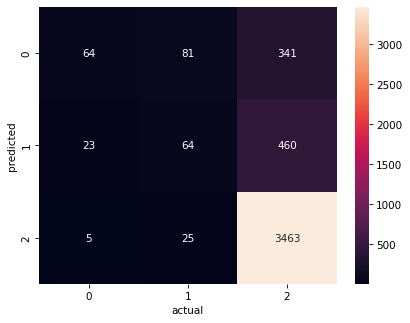

In [ ]:
# La confusion matrix conferma questa interpretazione con quasi la totalità delle etichette positive predette correttamente.
from sklearn.metrics import confusion_matrix

plt.figure(dpi=75)
matri = confusion_matrix(y_test, y_pred)
sns.heatmap(matri, annot=True, fmt='d')
plt.xlabel("actual")
plt.ylabel("predicted")
plt.show()

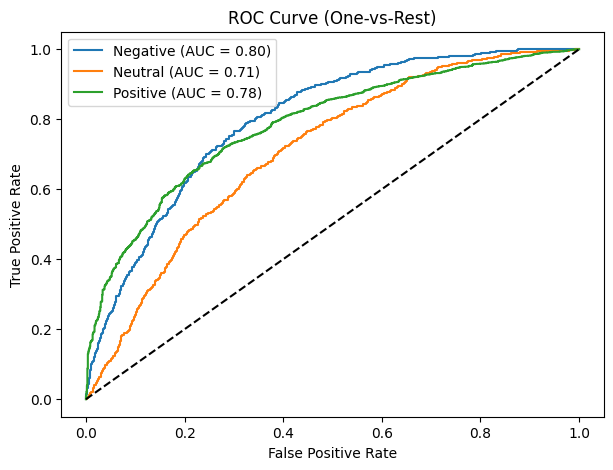

In [ ]:
# La curva ROC conferma la scarsa capacità del modello nel classificare le etichette neutrali rispetto alle altre due

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize

classes = ['Negative', 'Neutral', 'Positive']


y_test_bin = label_binarize(y_test, classes=classes)


prob = model_naive.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(7,5), dpi=100)

for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'{cls} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()



In [ ]:
# La Decision Tree Classifier migliora sesibilmente il parametro di recall, ovvero l'etichette effettivamente predette sia nel caso delle negative che in quelle neutral
# l'accuracy è scesa verso il 74%, ma il modello risulta più bilanciato. Questo vale per entrambe le matrici in input. Rispetto a Count Vectorizer
# La matrice TF-IDF è più bilanciata è ha una maggiore Accuracy,la prima si ferma al 73%.

from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier().fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))




0.7423773751657092
              precision    recall  f1-score   support

    Negative       0.34      0.28      0.31       486
     Neutral       0.25      0.21      0.23       547
    Positive       0.85      0.89      0.87      3493

    accuracy                           0.74      4526
   macro avg       0.48      0.46      0.47      4526
weighted avg       0.72      0.74      0.73      4526



In [ ]:
# Il modello Random Forest non tiene conto delle classi neutral e negative dato da un recall molto basso, equivalente allo zero.

from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(random_state=61).fit(X_train, y_train)
y_pred = model_forest.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.773972602739726
              precision    recall  f1-score   support

    Negative       0.62      0.02      0.03       486
     Neutral       0.29      0.00      0.01       547
    Positive       0.78      1.00      0.87      3493

    accuracy                           0.77      4526
   macro avg       0.56      0.34      0.30      4526
weighted avg       0.70      0.77      0.68      4526



In [ ]:
# SVM si rivela di gran lunga il miglior modello, con il 37% delle etichette negative identificate correttamente rispetto all'esempio precedente che non ne indovinava nessuna.
# Lo stesso vale per le f1 score negative che si avvicinano quasi al 50% con la Tf Idf . Le opinioni positive continuanon ad essere correttamente identificate ad un tasso maggiore, oltre il 90%.
# Utilizzando CountVectorizer non vi è un grande discostamento tra i due risultati, apparte un aumento dell'accuracy, due punti percentuale.


from sklearn.svm import SVC

model_svm = SVC(kernel='linear', probability=True, random_state=61).fit(X_train, y_train)
y_svmpred = model_svm.predict(X_test)

print(accuracy_score(y_test, y_svmpred))
print(classification_report(y_test, y_svmpred))

0.8210340256296951
              precision    recall  f1-score   support

    Negative       0.62      0.37      0.46       486
     Neutral       0.45      0.19      0.27       547
    Positive       0.86      0.98      0.92      3493

    accuracy                           0.82      4526
   macro avg       0.64      0.51      0.55      4526
weighted avg       0.78      0.82      0.79      4526



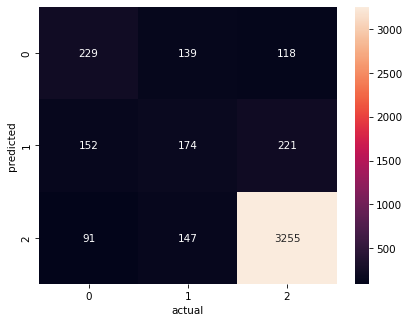

In [ ]:
plt.figure(dpi=75)
matri = confusion_matrix(y_test, y_svmpred)
sns.heatmap(matri, annot=True, fmt='d')
plt.xlabel("actual")
plt.ylabel("predicted")
plt.show()

#                                 **conclusioni**

Comparando i diversi modelli: Naive bayes, Decision tree Classifier, Random Forest e SVM applicate alle due matrici Count vectorizer e Tf Idf raggiungiamo le seguenti conclusioni:


*   Random Forest Classifier si rivela essere il modello peggiore nel riconoscimento delle etichette negative e neutrali con valori di recall equivalenti a zero.Questo indipendentemente dal vectorizer utilizzato.
* Tra Count Vectorizer e Tf Idf, il secondo è il migliore in quasi tutti i modelli utilizzati, eccetto Naive Bayes dove il primo primeggia non solo in termini di accuracy, 79% contro il 77 del secondo, ma anche nelle metriche di Recall e f1 score.
* Il modello SVM si rivela essere il migliore tra le altre opzioni in termini di Accuracy, 82%, per la sua capacità di attribuire con successo le etichette negative ad un tasso del 37% rispetto al 31% della Decision Tree, Mentre quest'ultimo  modello si dimostra leggermente migliore nell'identificazione delle opinioni neutre.





